In [1]:
from pathlib import Path

import cv2
import numpy as np
import pandas as pd


def _read_bgr(path: str) -> np.ndarray:
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(f"Could not read image: {path}")
    return img


def lab_histogram(image_bgr: np.ndarray, bins: int = 32) -> dict[str, np.ndarray]:
    """Normalized LAB channel histograms (L, A, B)."""
    lab = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2LAB)
    hists = {}
    for ch, name in enumerate("LAB"):
        hist = cv2.calcHist([lab], [ch], None, [bins], [0, 256]).ravel()
        hists[name] = hist / (hist.sum() + 1e-9)
    return hists


def dominant_palette(
    image_bgr: np.ndarray,
    n_colors: int = 5,
    sample_pixels: int = 10_000,
    seed: int = 42,
) -> list[dict]:
    """Top colors via k-means in RGB, sorted by pixel weight."""
    rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB).reshape(-1, 3).astype(np.float32)
    if len(rgb) > sample_pixels:
        rng = np.random.default_rng(seed)
        rgb = rgb[rng.choice(len(rgb), sample_pixels, replace=False)]

    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 20, 1.0)
    _, labels, centers = cv2.kmeans(
        rgb,
        n_colors,
        None,
        criteria,
        10,
        cv2.KMEANS_PP_CENTERS,
    )
    counts = np.bincount(labels.flatten(), minlength=n_colors)
    total = counts.sum()

    palette = []
    for idx in np.argsort(counts)[::-1]:
        palette.append(
            {
                "rgb": centers[idx].astype(int).tolist(),
                "weight": float(counts[idx] / total),
            }
        )
    return palette


def warm_cool_ratio(image_bgr: np.ndarray, sat_threshold: int = 30) -> dict[str, float]:
    """Warm vs cool split from saturated hue (red/yellow vs green/blue)."""
    hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
    hue = hsv[:, :, 0].astype(np.float32)
    sat = hsv[:, :, 1]
    chromatic = hue[sat > sat_threshold]

    if len(chromatic) == 0:
        return {"warm": 0.5, "cool": 0.5, "ratio": 1.0}

    warm = np.sum((chromatic <= 35) | (chromatic >= 150))
    cool = np.sum((chromatic > 35) & (chromatic < 150))
    total = warm + cool
    warm_frac = warm / total
    cool_frac = cool / total
    return {
        "warm": float(warm_frac),
        "cool": float(cool_frac),
        "ratio": float(warm / cool) if cool > 0 else float("inf"),
    }


def contrast_profile(image_bgr: np.ndarray, bins: int = 10) -> dict:
    """Global contrast metrics plus per-luminance-bin local contrast."""
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    lo, hi = int(gray.min()), int(gray.max())
    michelson = (hi - lo) / (hi + lo + 1e-6)

    edges = np.linspace(0, 256, bins + 1)
    profile = []
    for i in range(bins):
        lo_bin, hi_bin = edges[i], edges[i + 1]
        mask = (gray >= lo_bin) & (gray < hi_bin)
        profile.append(
            {
                "range": (float(lo_bin), float(hi_bin)),
                "fraction": float(mask.mean()),
                "local_std": float(gray[mask].std()) if mask.any() else 0.0,
            }
        )

    return {
        "mean_luminance": float(gray.mean()),
        "global_std": float(gray.std()),
        "michelson": float(michelson),
        "bins": profile,
    }


def extract_color_features(image_bgr: np.ndarray) -> dict:
    return {
        "lab_histogram": lab_histogram(image_bgr),
        "dominant_palette": dominant_palette(image_bgr),
        "warm_cool_ratio": warm_cool_ratio(image_bgr),
        "contrast_profile": contrast_profile(image_bgr),
    }


def lab_histogram_vector(hists: dict[str, np.ndarray]) -> np.ndarray:
    return np.concatenate([hists["L"], hists["A"], hists["B"]])


def lab_histogram_similarity(a: dict[str, np.ndarray], b: dict[str, np.ndarray]) -> float:
    va = lab_histogram_vector(a)
    vb = lab_histogram_vector(b)
    return float(np.dot(va, vb) / (np.linalg.norm(va) * np.linalg.norm(vb) + 1e-9))

In [2]:
DATA_PATH = Path("data/img-metadata-CC0-clean.csv")
SAMPLE_SIZE = 100
RANDOM_SEED = 42
CACHE_DIR = Path("data/color_sample")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

data = pd.read_csv(DATA_PATH, low_memory=False)
sample = (
    data.dropna(subset=["image_web"])
    .sample(SAMPLE_SIZE, random_state=RANDOM_SEED)
    .reset_index(drop=True)
)
sample[["accession_number", "title", "image_web"]].head()

,accession_number,title,image_web
0,1962.279.242.a,Mahrusa kills herself at the tomb of the king ...,https://openaccess-cdn.clevelandart.org/1962.2...
1,1921.965,The Early Plowman,https://openaccess-cdn.clevelandart.org/1921.9...
2,1952.260,Portrait Head of a Noble or Official,https://openaccess-cdn.clevelandart.org/1952.2...
3,1920.1975,Trial Piece Worked on Both Sides,https://openaccess-cdn.clevelandart.org/1920.1...
4,1982.179.47,Reynard the Fox: Reynard Promises Gifts to th...,https://openaccess-cdn.clevelandart.org/1982.1...


In [3]:
import urllib.request

from tqdm.contrib.concurrent import thread_map


def download_image(item):
    acc, url = item
    path = CACHE_DIR / f"{acc}.jpg"
    if path.exists():
        return acc, str(path)
    try:
        req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(req, timeout=60) as response:
            path.write_bytes(response.read())
        return acc, str(path)
    except Exception:
        return acc, None


tasks = list(sample[["accession_number", "image_web"]].itertuples(index=False, name=None))
download_results = thread_map(
    download_image,
    tasks,
    max_workers=16,
    desc="Downloading images",
)
paths = {acc: path for acc, path in download_results if path}
len(paths), len(sample) - len(paths)

/home/arjun/projects/ArtButSports/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(100, 0)

In [4]:
records = []

for _, row in sample.iterrows():
    path = paths.get(row["accession_number"])
    if not path:
        continue
    img = cv2.imread(path)
    if img is None:
        continue

    features = extract_color_features(img)
    records.append(
        {
            "accession_number": row["accession_number"],
            "title": row["title"],
            "path": path,
            "image_bgr": img,
            **features,
        }
    )

len(records)

100

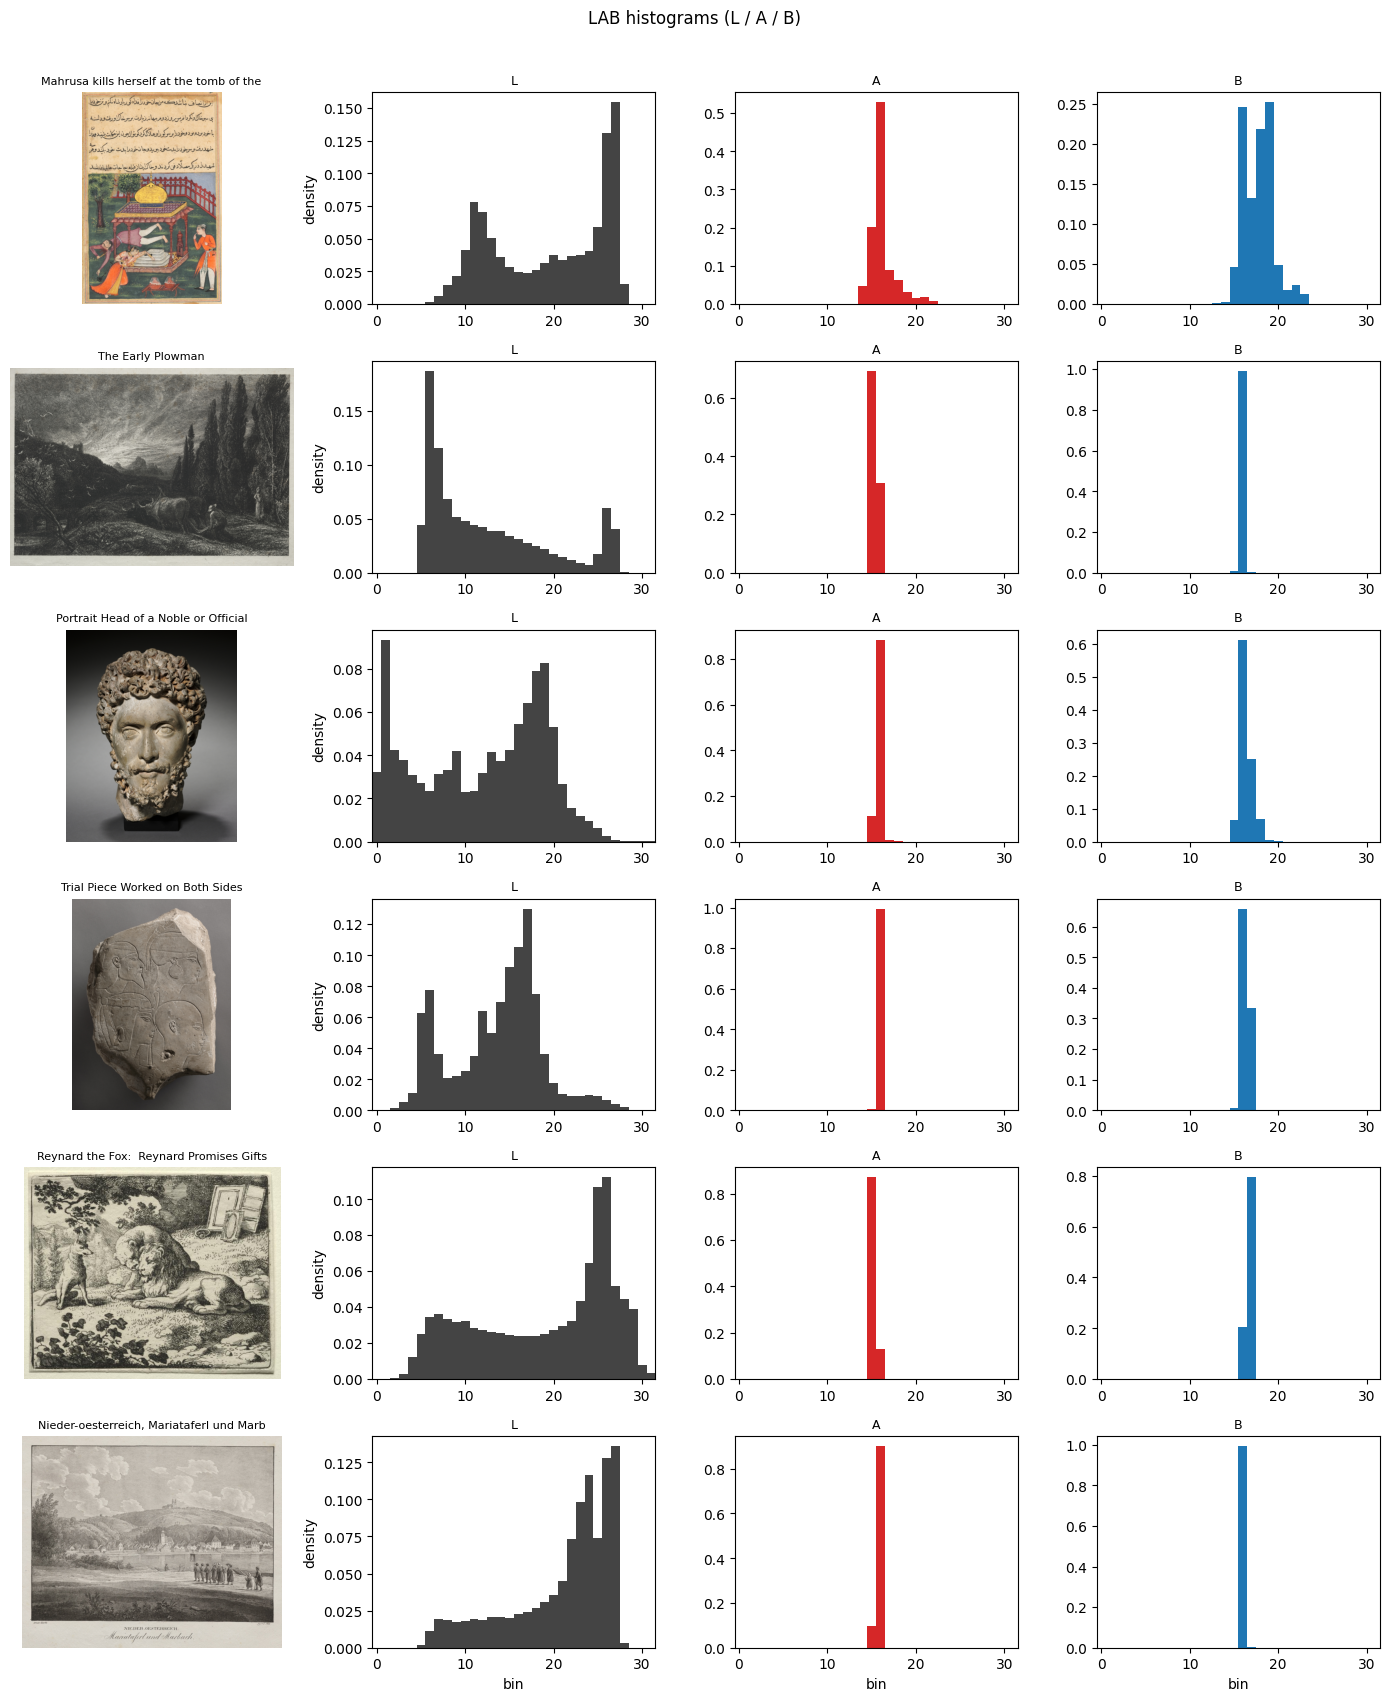

In [5]:
import matplotlib.pyplot as plt

N_SHOW = 6
fig, axes = plt.subplots(N_SHOW, 4, figsize=(14, 2.8 * N_SHOW))
fig.suptitle("LAB histograms (L / A / B)", y=1.01)

channel_colors = {"L": "#444444", "A": "#d62728", "B": "#1f77b4"}

for i in range(min(N_SHOW, len(records))):
    rec = records[i]
    hists = rec["lab_histogram"]
    bins = np.arange(len(hists["L"]))

    axes[i, 0].imshow(cv2.cvtColor(rec["image_bgr"], cv2.COLOR_BGR2RGB))
    axes[i, 0].set_title(str(rec["title"])[:40], fontsize=8)
    axes[i, 0].axis("off")

    for j, ch in enumerate("LAB"):
        ax = axes[i, j + 1]
        ax.bar(bins, hists[ch], color=channel_colors[ch], width=1.0)
        ax.set_title(ch, fontsize=9)
        ax.set_xlim(-0.5, len(bins) - 0.5)
        if i == N_SHOW - 1:
            ax.set_xlabel("bin")
        if j == 0:
            ax.set_ylabel("density")

plt.tight_layout()
plt.show()

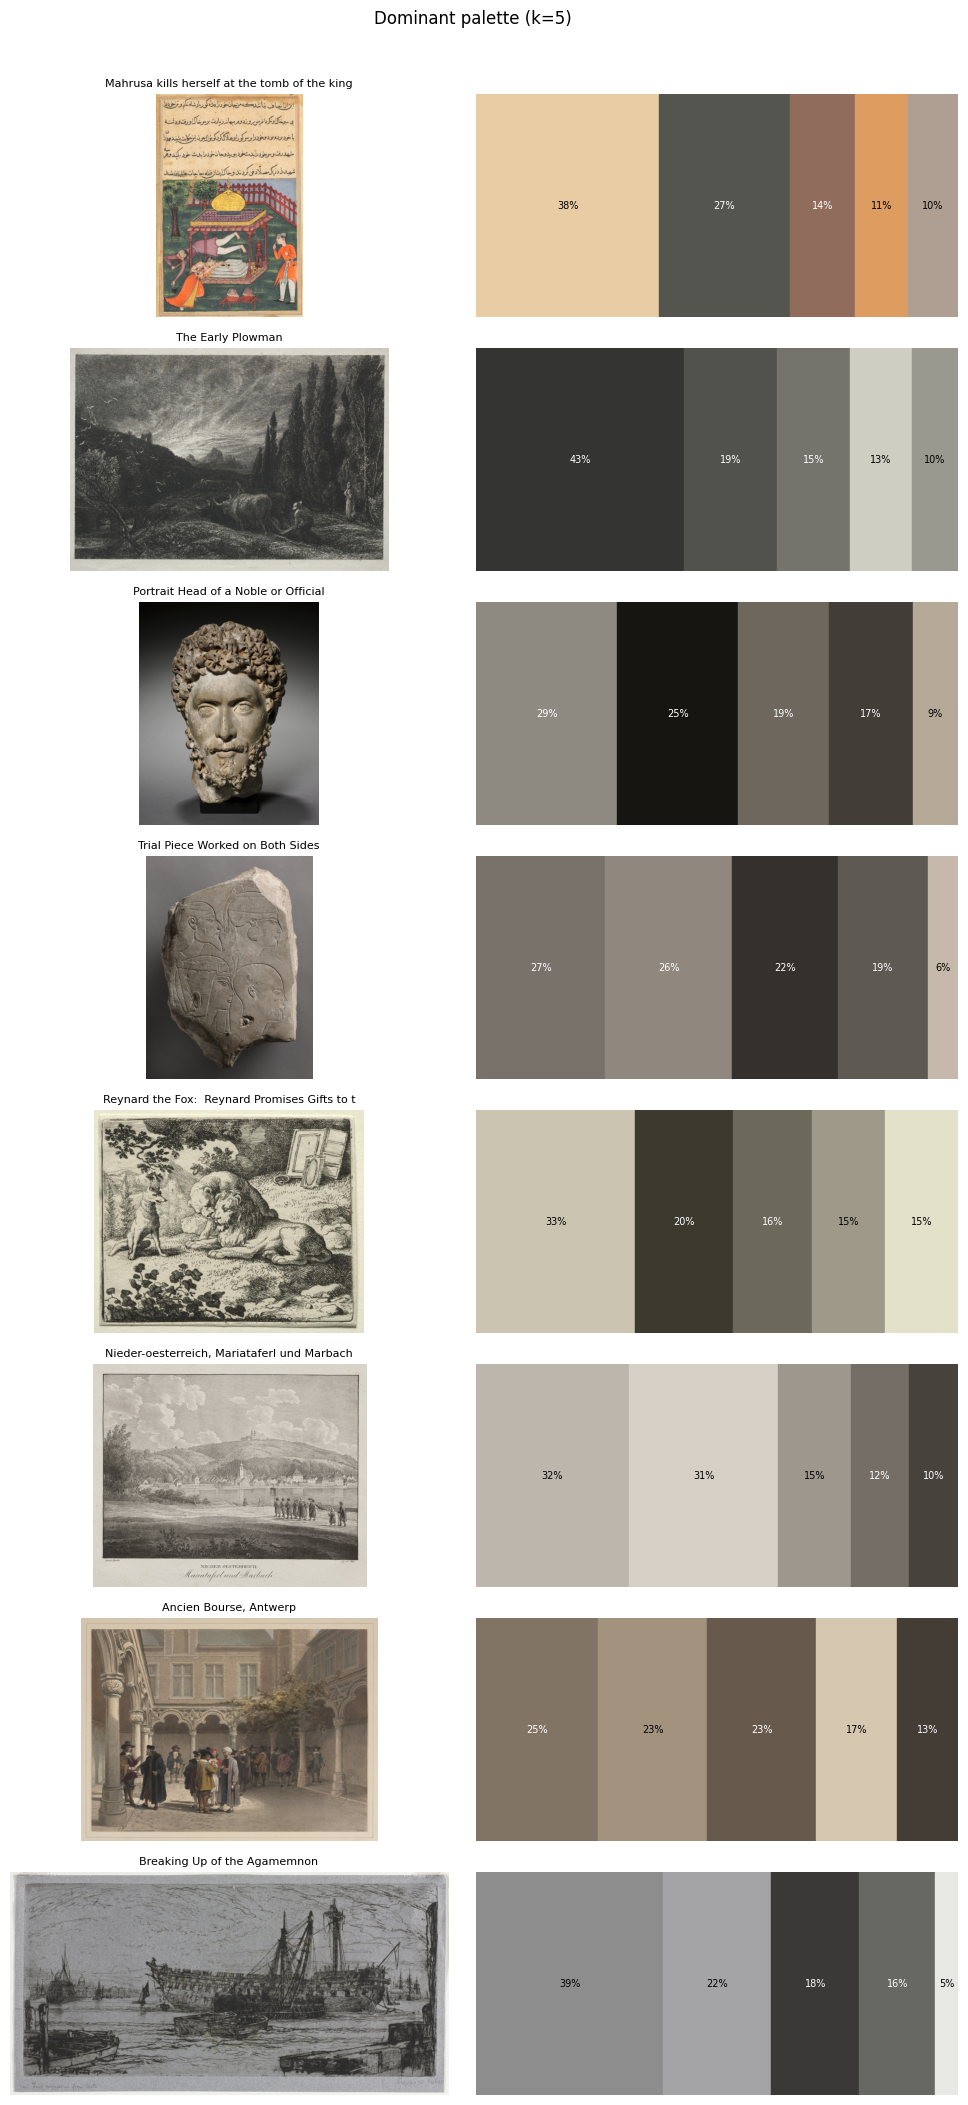

In [6]:
N_SHOW = 8
fig, axes = plt.subplots(N_SHOW, 2, figsize=(10, 2.6 * N_SHOW))
fig.suptitle("Dominant palette (k=5)", y=1.01)

for i in range(min(N_SHOW, len(records))):
    rec = records[i]
    palette = rec["dominant_palette"]

    axes[i, 0].imshow(cv2.cvtColor(rec["image_bgr"], cv2.COLOR_BGR2RGB))
    axes[i, 0].set_title(str(rec["title"])[:45], fontsize=8)
    axes[i, 0].axis("off")

    swatch_ax = axes[i, 1]
    swatch_ax.set_xlim(0, 1)
    swatch_ax.set_ylim(0, 1)
    swatch_ax.axis("off")

    x = 0.0
    for swatch in palette:
        w = swatch["weight"]
        rgb = np.array(swatch["rgb"]) / 255.0
        swatch_ax.add_patch(plt.Rectangle((x, 0), w, 1, color=rgb))
        swatch_ax.text(
            x + w / 2,
            0.5,
            f"{w:.0%}",
            ha="center",
            va="center",
            fontsize=7,
            color="white" if rgb.mean() < 0.55 else "black",
        )
        x += w

plt.tight_layout()
plt.show()

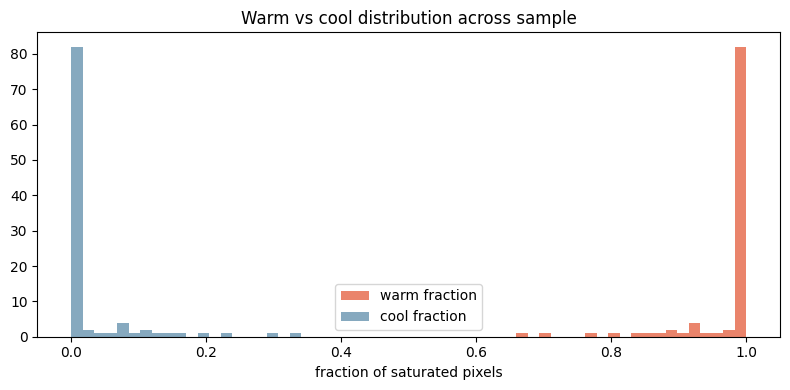

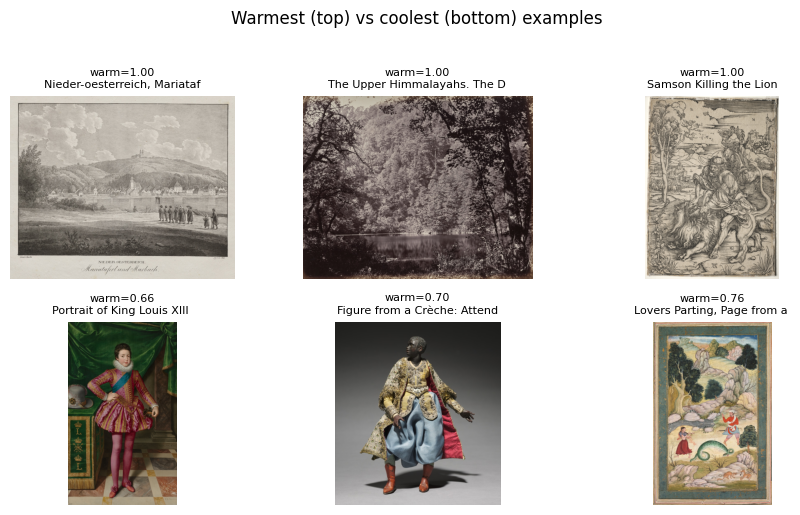

,accession_number,title,warm,cool,ratio
15,1935.26,Reclining Nude,1.0,0.0,inf
9,1948.121,Samson Killing the Lion,1.0,0.0,inf
8,2024.5.25,The Upper Himmalayahs. The Dodee Tal in Lake,1.0,0.0,inf
5,1968.298,"Nieder-oesterreich, Mariataferl und Marbach",1.0,0.0,inf
28,2022.132,A View of the Stairs of the Vatican,1.0,0.0,inf


In [7]:
warm_cool_df = pd.DataFrame(
    [
        {
            "accession_number": r["accession_number"],
            "title": r["title"],
            "path": r["path"],
            **r["warm_cool_ratio"],
        }
        for r in records
    ]
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(warm_cool_df["warm"], bins=20, color="#e76f51", alpha=0.85, label="warm fraction")
ax.hist(warm_cool_df["cool"], bins=20, color="#457b9d", alpha=0.65, label="cool fraction")
ax.set_title("Warm vs cool distribution across sample")
ax.set_xlabel("fraction of saturated pixels")
ax.legend()
plt.tight_layout()
plt.show()

warmest = warm_cool_df.nlargest(3, "warm")
coolest = warm_cool_df.nsmallest(3, "warm")

fig, axes = plt.subplots(2, 3, figsize=(9, 5))
fig.suptitle("Warmest (top) vs coolest (bottom) examples", y=1.02)

for k, (_, row) in enumerate(warmest.iterrows()):
    img = cv2.cvtColor(cv2.imread(row["path"]), cv2.COLOR_BGR2RGB)
    axes[0, k].imshow(img)
    axes[0, k].set_title(f"warm={row['warm']:.2f}\n{row['title'][:28]}", fontsize=8)
    axes[0, k].axis("off")

for k, (_, row) in enumerate(coolest.iterrows()):
    img = cv2.cvtColor(cv2.imread(row["path"]), cv2.COLOR_BGR2RGB)
    axes[1, k].imshow(img)
    axes[1, k].set_title(f"warm={row['warm']:.2f}\n{row['title'][:28]}", fontsize=8)
    axes[1, k].axis("off")

plt.tight_layout()
plt.show()

warm_cool_df[["accession_number", "title", "warm", "cool", "ratio"]].sort_values("warm", ascending=False).head()

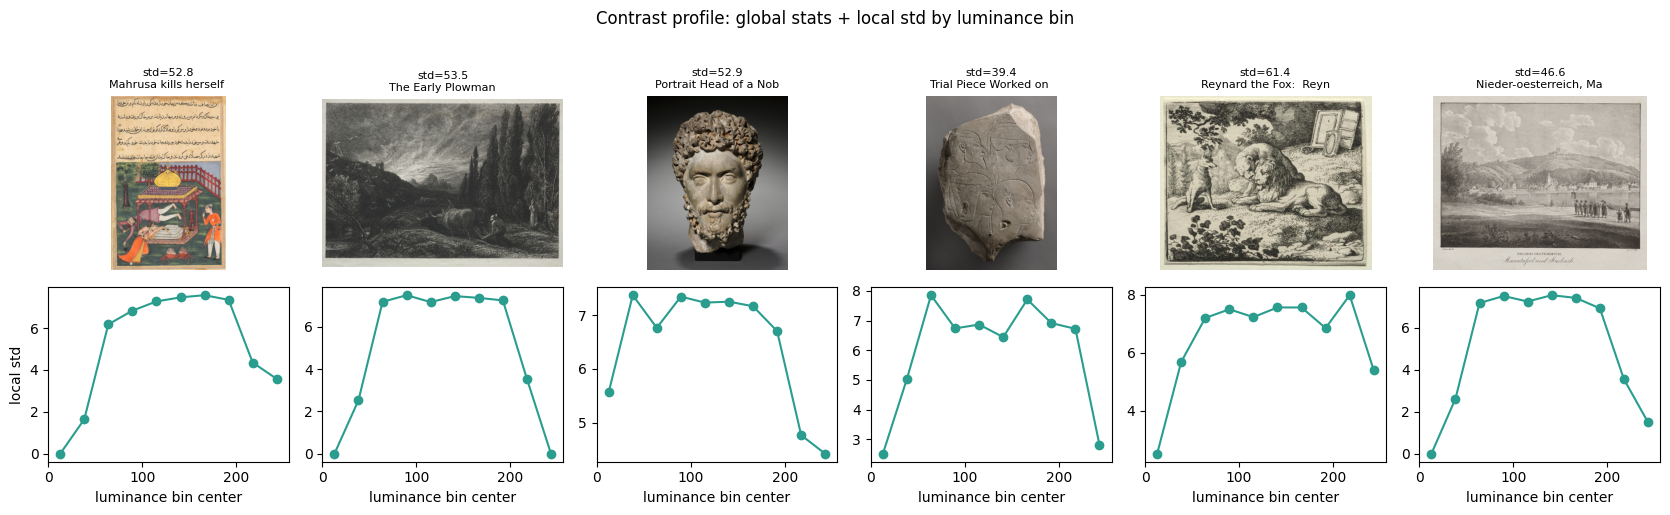

,accession_number,title,global_std,michelson,mean_luminance
43,1919.696,The Smuggler's Landing Place,74.067307,0.976471,145.283492
55,2012.271,Ten Assassinations for a Penny,68.894330,0.702422,153.453914
66,1929.33,Carnaval,68.128906,0.976562,178.227983
57,1963.86,Mountain Landscape with Fir Trees,67.739992,0.946154,160.423664
72,1941.20,Kangaroo,66.725621,1.000000,80.308679


In [8]:
N_SHOW = 6
fig, axes = plt.subplots(2, N_SHOW, figsize=(2.8 * N_SHOW, 5))
fig.suptitle("Contrast profile: global stats + local std by luminance bin", y=1.02)

for i in range(min(N_SHOW, len(records))):
    rec = records[i]
    profile = rec["contrast_profile"]
    centers = [(b["range"][0] + b["range"][1]) / 2 for b in profile["bins"]]
    local_std = [b["local_std"] for b in profile["bins"]]

    axes[0, i].imshow(cv2.cvtColor(rec["image_bgr"], cv2.COLOR_BGR2RGB))
    axes[0, i].set_title(
        f"std={profile['global_std']:.1f}\n{str(rec['title'])[:22]}",
        fontsize=8,
    )
    axes[0, i].axis("off")

    axes[1, i].plot(centers, local_std, marker="o", color="#2a9d8f")
    axes[1, i].set_xlim(0, 256)
    axes[1, i].set_xlabel("luminance bin center")
    if i == 0:
        axes[1, i].set_ylabel("local std")

plt.tight_layout()
plt.show()

contrast_df = pd.DataFrame(
    [
        {
            "accession_number": r["accession_number"],
            "title": r["title"],
            "global_std": r["contrast_profile"]["global_std"],
            "michelson": r["contrast_profile"]["michelson"],
            "mean_luminance": r["contrast_profile"]["mean_luminance"],
        }
        for r in records
    ]
).sort_values("global_std", ascending=False)
contrast_df.head()

,rank,accession_number,title,similarity
0,1,1962.279.242.a,Mahrusa kills herself at the tomb of the king ...,1.000000
1,2,1962.279.241.a,The king of Zabul sees Mahrusa from his palace...,0.939861
2,3,1938.301.164.b,"Text, folio 164 (verso), from a Manuscript of ...",0.915661
3,4,1962.279.168.b,"Habbaza meets Bashir under a tree, from a Tuti...",0.913940
4,5,2013.303.a,"Lovers Parting, Page from a Book of Fables",0.911512


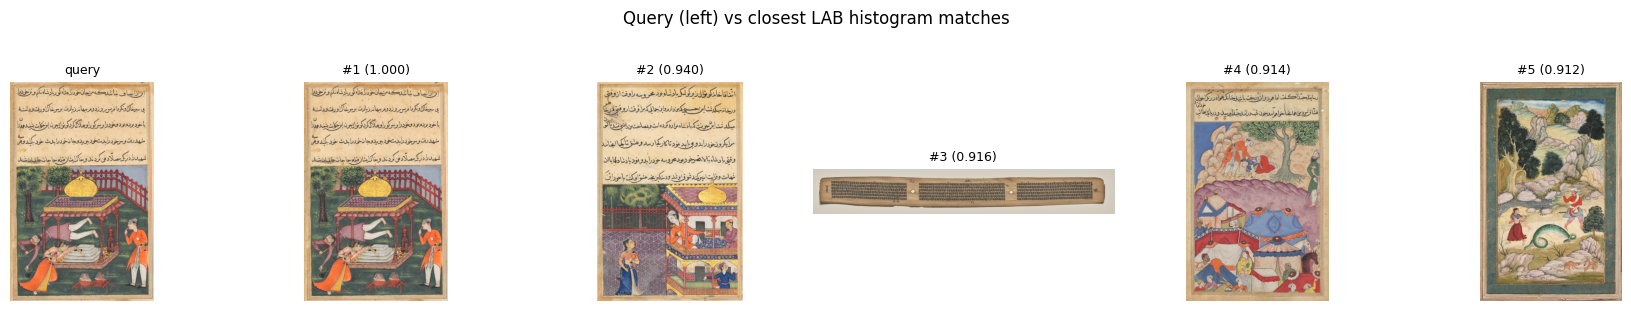

In [9]:
def search_by_lab_color(query_path: str, top_k: int = 5) -> pd.DataFrame:
    query_img = _read_bgr(query_path)
    query_hist = lab_histogram(query_img)

    scores = []
    for rec in records:
        sim = lab_histogram_similarity(query_hist, rec["lab_histogram"])
        scores.append(
            {
                "accession_number": rec["accession_number"],
                "title": rec["title"],
                "path": rec["path"],
                "similarity": sim,
            }
        )

    return (
        pd.DataFrame(scores)
        .sort_values("similarity", ascending=False)
        .head(top_k)
        .reset_index(drop=True)
        .assign(rank=lambda df: np.arange(1, len(df) + 1))
    )


QUERY_IMAGE = records[0]["path"]
TOP_K = 5
results = search_by_lab_color(QUERY_IMAGE, top_k=TOP_K)
display(results[["rank", "accession_number", "title", "similarity"]])

fig, axes = plt.subplots(1, TOP_K + 1, figsize=(3 * (TOP_K + 1), 3))
fig.suptitle("Query (left) vs closest LAB histogram matches", y=1.02)

query_rgb = cv2.cvtColor(_read_bgr(QUERY_IMAGE), cv2.COLOR_BGR2RGB)
axes[0].imshow(query_rgb)
axes[0].set_title("query", fontsize=9)
axes[0].axis("off")

for i, (_, row) in enumerate(results.iterrows()):
    img = cv2.cvtColor(_read_bgr(row["path"]), cv2.COLOR_BGR2RGB)
    axes[i + 1].imshow(img)
    axes[i + 1].set_title(f"#{row['rank']} ({row['similarity']:.3f})", fontsize=9)
    axes[i + 1].axis("off")

plt.tight_layout()
plt.show()